# Predicting Familial Hypercholesterolemia from Genomic Variant Expression Data

---

| | |
|---|---|
| **Author** | Lilac Zihui Zhao |
| **Date** | 31st March 2025 |

---

## Executive Summary

This study evaluates whether genomic variant expression data can be used to predict Familial Hypercholesterolaemia (FH) — a genetic condition causing reduced LDL clearance and elevated cardiovascular risk — and which gene variants and demographic factors are most associated with the disease.

This notebook delivers a complete pipeline addressing three questions: 
    1) predictive modelling, gene variant importance, and demographic correlations. Key findings and dataset limitations are summarised below.

---

## Analysis Structure

| Section | |
|---|---|
| **1. Exploratory Data Analysis** | Data structure, clinical variable associations |
| **2. Dimensionality Reduction** | PCA and UMAP |
| **3. Differential Expression Analysis** | Volcano plot and bubble plot |
| **4. Predictive Modelling** | LASSO, Random Forest, SVM |
| **5. Feature Importance** | Random Forest and LASSO |
| **6.Limitations & Recommendations** | |

---

## Key Findings

| Director's Question | Finding |
|---|---|
| **How do demographics correlate with FH?** | All four variables significantly associated (p < 0.001) — FH patients are older, more likely male, more sedentary, and report poorer mental wellbeing |
| **Which gene variants are most influential?** | Var_X100248 (most strongly downregulated) and Var_X100251 (most strongly upregulated) — consistent across RF and LASSO |
| **Can FH be predicted from gene variant data?** | Yes — SVM achieves AUC = 0.999, 100% FH recall and 98% specificity on held-out test set |
| **Dataset limitations?** | class imbalance (80/20), anonymised gene labels, no LDL panel, no longitudinal follow-up |

In [2]:
import numpy  as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot  as plt
import seaborn            as sns


from scipy                          import stats
from statsmodels.stats.multitest    import multipletests
import statsmodels.api as sm


from sklearn.compose        import ColumnTransformer
from sklearn.preprocessing  import LabelEncoder, OrdinalEncoder, StandardScaler


from sklearn.decomposition  import PCA
from umap import UMAP          # then use UMAP(...) directly


from sklearn.pipeline       import Pipeline
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC


from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)


from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

from sklearn.inspection import permutation_importance



BUPA_BLUE   = "#003087"
BUPA_TEAL   = "#00A3A1"
ACCENT_RED  = "#D85A30"
ACCENT_GREY = "#888780"

sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi"         : 120,
    "axes.titlesize"     : 14,
    "axes.titleweight"   : "bold",
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
})

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


## Section 1 — Exploratory Data Analysis 

## Inspect the dataset structure


In [3]:
# load data
df = pd.read_excel("/Users/lilac/Dropbox/DS/data_set_gene_exp.xlsx", sheet_name="Data")

In [4]:
# dataset overview: sample size, columns, column types

gene_cols = [c for c in df.columns if c.startswith("Var_X")]
cov_cols  = ["Age", "Sex", "Physical_activity", "Mental_wellbeing"]
target    = "Disease_state"

print("=" * 55)
print("  Dataset overview")
print("=" * 55)
print(f"  Sample size              : {df.shape[0]:,}")
print(f"  Genetic variant exp cols : {len(gene_cols):,}")
print(f"  Demographic and self-reported health covariates   : {len(cov_cols)}")
print("=" * 55)

print("\n  Column types (non-gene):")
print(df[cov_cols + [target]].dtypes.to_string())
print(f"  Genetic variant features : {df[gene_cols].dtypes.unique()} (all)")

  Dataset overview
  Sample size              : 2,761
  Genetic variant exp cols : 265
  Demographic and self-reported health covariates   : 4

  Column types (non-gene):
Age                   int64
Sex                  object
Physical_activity    object
Mental_wellbeing     object
Disease_state        object
  Genetic variant features : [dtype('float64')] (all)


In [5]:
# inspect missing rates 
df.isna().mean().sort_values(ascending = False)

Disease_state    0.0
Var_X100180      0.0
Var_X100166      0.0
Var_X100167      0.0
Var_X100168      0.0
                ... 
Var_X100090      0.0
Var_X100091      0.0
Var_X100092      0.0
Var_X100093      0.0
Var_X100264      0.0
Length: 270, dtype: float64

In [6]:
# inspect target outcome distribution
print("\n" + "=" * 55)
print("  Target outcome distribution")
print("=" * 55)
vc = df[target].value_counts()
for label, count in vc.items():
    print(f"  {label:<40}: {count:,} ({count/len(df)*100:.1f}%)")



  Target outcome distribution
  Familial_hypercholesterolemia           : 2,213 (80.2%)
  None                                    : 548 (19.8%)


In [7]:
# inspect categorical covariate distribution
print("\n" + "=" * 55)
print("  Categorical covariate distributions")
print("=" * 55)

orders = {
    "Physical_activity" : ["Sedentary", "Light intensity", "Moderate intensity", "Vigorous intensity"],
    "Mental_wellbeing"  : ["Very poor", "Poor", "Fair", "Good", "Very good"],
    "Sex"               : df["Sex"].value_counts().index.tolist(),
}

for col, order in orders.items():
    print(f"\n  {col}:")
    vc = df[col].value_counts()
    for val in order:
        cnt = vc[val]
        print(f"    {val:<25}: {cnt:,} ({cnt/len(df)*100:.1f}%)")


  Categorical covariate distributions

  Physical_activity:
    Sedentary                : 852 (30.9%)
    Light intensity          : 708 (25.6%)
    Moderate intensity       : 940 (34.0%)
    Vigorous intensity       : 261 (9.5%)

  Mental_wellbeing:
    Very poor                : 416 (15.1%)
    Poor                     : 955 (34.6%)
    Fair                     : 884 (32.0%)
    Good                     : 359 (13.0%)
    Very good                : 147 (5.3%)

  Sex:
    Female                   : 1,421 (51.5%)
    Male                     : 1,340 (48.5%)


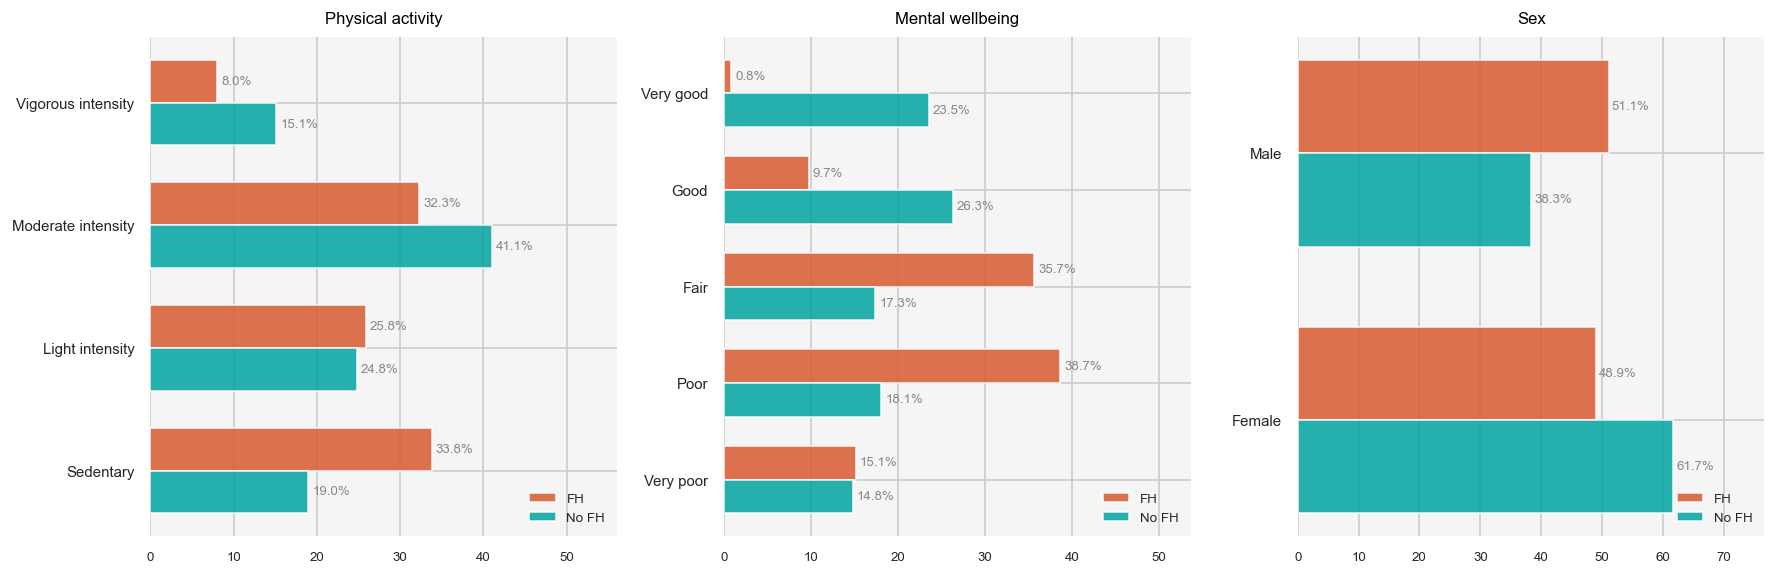

In [8]:
y_labels = pd.Series(
    (df[target] == "Familial_hypercholesterolemia").map({True: "FH", False: "No FH"})
)

# compute % within each group for each categorical variable
def group_pcts(col, categories):
    ct = pd.crosstab(df[col], y_labels, normalize="columns") * 100
    fh   = [ct.loc[c, "FH"]    for c in categories]
    nofh = [ct.loc[c, "No FH"] for c in categories]
    return fh, nofh

# grouped horizontal bar chart: FH vs No FH per category
def plot_grouped_hbar(ax, categories, fh_vals, nofh_vals, title):
    ax.set_facecolor("#F5F5F5")
    for spine in ax.spines.values():
        spine.set_visible(False)
    n      = len(categories)
    y      = np.arange(n)
    height = 0.35
    b1 = ax.barh(y + height/2, fh_vals,   height=height, color=ACCENT_RED, alpha=0.85, label="FH")
    b2 = ax.barh(y - height/2, nofh_vals, height=height, color=BUPA_TEAL,  alpha=0.85, label="No FH")
    for bar, val in zip(b1, fh_vals):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=8, color=ACCENT_GREY)
    for bar, val in zip(b2, nofh_vals):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=8, color=ACCENT_GREY)
    ax.set_yticks(y)
    ax.set_yticklabels(categories, fontsize=9)
    ax.set_xlim(0, max(fh_vals + nofh_vals) + 15)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_title(title, fontsize=10, color="black", pad=8, fontweight="normal")
    ax.legend(frameon=False, fontsize=8, loc="lower right")

# distribution summary charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("white")

# physical activity
pa_cats = ["Sedentary", "Light intensity", "Moderate intensity", "Vigorous intensity"]
fh_pa, nofh_pa = group_pcts("Physical_activity", pa_cats)
plot_grouped_hbar(axes[0], pa_cats, fh_pa, nofh_pa, "Physical activity")

# mental wellbeing
mw_cats = ["Very poor", "Poor", "Fair", "Good", "Very good"]
fh_mw, nofh_mw = group_pcts("Mental_wellbeing", mw_cats)
plot_grouped_hbar(axes[1], mw_cats, fh_mw, nofh_mw, "Mental wellbeing")

# sex
sx_cats = ["Female", "Male"]
fh_sx, nofh_sx = group_pcts("Sex", sx_cats)
plot_grouped_hbar(axes[2], sx_cats, fh_sx, nofh_sx, "Sex")

plt.tight_layout()
plt.savefig("fig_distributions.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

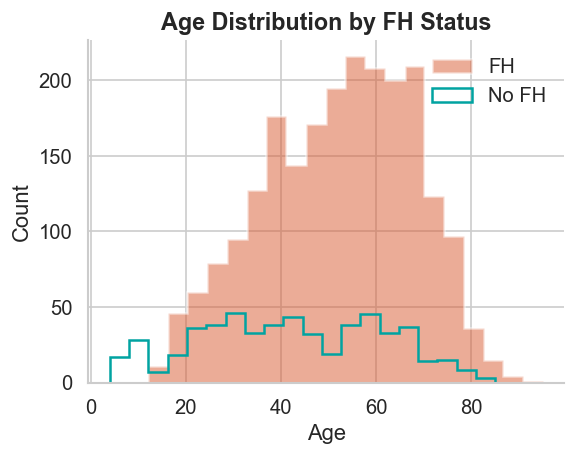

In [9]:
# inspect age distribution by fh status
fig, ax = plt.subplots(figsize=(5, 4))
for label, color, histtype, alpha in [("FH",    ACCENT_RED, "stepfilled", 0.5),
                                       ("No FH", BUPA_TEAL,  "step",       1.0)]:
    ax.hist(df.loc[y_labels == label, "Age"],
            bins=20, color=color, label=label,
            histtype=histtype, alpha=alpha, linewidth=1.5)
ax.set_title("Age Distribution by FH Status")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig_age_distribution_by_fhstatus.png", dpi=100, bbox_inches="tight")
plt.show()

## Logistic regression 

**Objective:** Investigate how demographic and self-reported health measures correlate with FH status.

In [10]:
# =============================================================================
# Logistic regression 
# =============================================================================

# target variable
y = (df[target] == "Familial_hypercholesterolemia").astype(int)

# dummy encode categorical variables, drop base categories
df_model = pd.get_dummies(
    df[["Age", "Sex", "Physical_activity", "Mental_wellbeing"]],
    drop_first=False
).drop(columns=["Sex_Female",
                 "Physical_activity_Sedentary",
                 "Mental_wellbeing_Very poor"])

# fit logistic regression with statsmodels for p-values and CIs
X      = sm.add_constant(df_model.astype(float))
lr_sm  = sm.Logit(y, X).fit(disp=0)

# variable name mapping
var_labels = {
    "Age"                              : "Age",
    "Sex_Male"                         : "Sex: Male",
    "Physical_activity_Light intensity": "Physical Activity: Light",
    "Physical_activity_Moderate intensity": "Physical Activity: Moderate",
    "Physical_activity_Vigorous intensity": "Physical Activity: Vigorous",
    "Mental_wellbeing_Poor"            : "Mental Wellbeing: Poor",
    "Mental_wellbeing_Fair"            : "Mental Wellbeing: Fair",
    "Mental_wellbeing_Good"            : "Mental Wellbeing: Good",
    "Mental_wellbeing_Very good"       : "Mental Wellbeing: Very Good",
}

# summary table: odds ratios, 95% CI, and p-values
results_df = pd.DataFrame({
    "Variable"  : [var_labels.get(v, v) for v in lr_sm.params.index],
    "Odds Ratio": [f"{np.exp(b):.2f}" for b in lr_sm.params],
    "95% CI"    : [f"({np.exp(lo):.2f}, {np.exp(hi):.2f})"
                    for lo, hi in zip(lr_sm.conf_int()[0], lr_sm.conf_int()[1])],
    "p-value"   : [f"< 0.001" if p < 0.001 else f"{p:.3f}" for p in lr_sm.pvalues],
}).reset_index(drop=True)

results_df = results_df[results_df["Variable"] != "const"]

ref_rows = [
    {"Variable": "Sex: Female (ref)",                    "Odds Ratio": "1.00", "95% CI": "—", "p-value": "—"},
    {"Variable": "Physical Activity: Sedentary (ref)",   "Odds Ratio": "1.00", "95% CI": "—", "p-value": "—"},
    {"Variable": "Mental Wellbeing: Very Poor (ref)",    "Odds Ratio": "1.00", "95% CI": "—", "p-value": "—"},
]

ordered_vars = [
    "Age",
    "Sex: Female (ref)", "Sex: Male",
    "Physical Activity: Sedentary (ref)", "Physical Activity: Light",
    "Physical Activity: Moderate", "Physical Activity: Vigorous",
    "Mental Wellbeing: Very Poor (ref)", "Mental Wellbeing: Poor",
    "Mental Wellbeing: Fair", "Mental Wellbeing: Good", "Mental Wellbeing: Very Good",
]

for ref_row in ref_rows:
    results_df = pd.concat([results_df, pd.DataFrame([ref_row])], ignore_index=True)

results_df["Variable"] = pd.Categorical(results_df["Variable"], categories=ordered_vars, ordered=True)
results_df = results_df.sort_values("Variable").reset_index(drop=True)

results_df.style \
    .set_caption("Logistic Regression — Odds Ratios for FH Status") \
    .set_properties(**{"text-align": "left", "font-size": "11px", "padding": "4px 8px"}) \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "12px"), ("font-weight", "bold"),
                                          ("color", "#003087"), ("padding-bottom", "6px")]},
        {"selector": "th",      "props": [("background-color", "#003087"), ("color", "white"),
                                          ("font-size", "11px"), ("padding", "4px 8px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f8ff")]},
    ]) \
    .hide(axis="index")

Variable,Odds Ratio,95% CI,p-value
Age,1.04,"(1.03, 1.05)",< 0.001
Sex: Female (ref),1.00,—,—
Sex: Male,1.86,"(1.48, 2.33)",< 0.001
Physical Activity: Sedentary (ref),1.00,—,—
Physical Activity: Light,0.53,"(0.38, 0.74)",< 0.001
Physical Activity: Moderate,0.34,"(0.25, 0.47)",< 0.001
Physical Activity: Vigorous,0.42,"(0.28, 0.65)",< 0.001
Mental Wellbeing: Very Poor (ref),1.00,—,—
Mental Wellbeing: Poor,2.29,"(1.63, 3.22)",< 0.001
Mental Wellbeing: Fair,2.03,"(1.43, 2.88)",< 0.001


## Dimensionality Reduction: PCA & UMAP

**Objective:** Investigate whether gene expression profiles naturally separate FH from No FH individuals, and assess whether FH signal is driven by a single dominant gene or distributed across many variants.

| Method |  ||
|:---|:---|:---|
| **PCA** | Linear projection onto axes of maximum variance 
| **UMAP** | Non-linear embedding preserving local neighbourhood structure 

**Key findings:**

- Signal is spread across many components — no single dominant gene driving FH
- No clear cluster separation in PCA 
- UMAP captures non-linear structure beyond PCA's reach
- Clearer FH vs No FH separation visible in UMAP 

/Applications/anaconda3/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


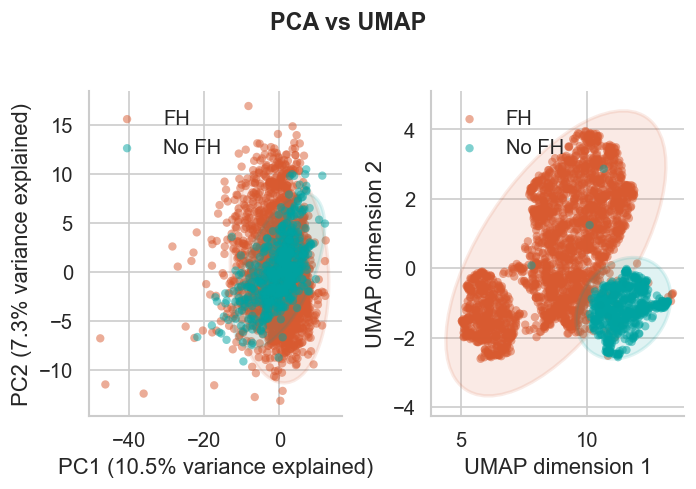

In [12]:
import umap

    
# define gene expression feature matrix
X_genes = df[gene_cols].values

# fit PCA
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_genes)
pca      = PCA(n_components=10, random_state=42)
pcs_all  = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_ * 100

# fit UMAP
reducer    = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
umap_embed = reducer.fit_transform(X_scaled)

def add_ellipse(ax, pts, color):
    cov        = np.cov(pts.T)
    mean       = pts.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order      = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta      = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h       = 2 * 2.45 * np.sqrt(vals)
    ell        = mpatches.Ellipse(xy=mean, width=w, height=h, angle=theta,
                                  edgecolor=color, facecolor=color,
                                  alpha=0.12, linewidth=2)
    ax.add_patch(ell)

# plot: PCA + UMAP 
fig, axes  = plt.subplots(1, 2, figsize=(6, 4))
colors_map = {"FH": ACCENT_RED, "No FH": BUPA_TEAL}

# PCA scatter
for grp, color in colors_map.items():
    mask = y_labels == grp
    axes[0].scatter(pcs_all[mask, 0], pcs_all[mask, 1],
                    color=color, alpha=0.5, s=25, label=grp, edgecolors="none")
    add_ellipse(axes[0], pcs_all[mask][:, :2], color)
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance explained)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance explained)")
axes[0].legend(frameon=False)

# UMAP scatter
for grp, color in colors_map.items():
    mask = y_labels == grp
    axes[1].scatter(umap_embed[mask, 0], umap_embed[mask, 1],
                    color=color, alpha=0.5, s=25, label=grp, edgecolors="none")
    add_ellipse(axes[1], umap_embed[mask], color)
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")
axes[1].legend(frameon=False)

plt.suptitle("PCA vs UMAP",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_pca_umap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Volcano Plot: Which Gene Variants Are Most Altered?

A volcano plot combines statistical significance (y-axis) and effect size (x-axis) to identify genes that are both meaningfully and reliably different between FH and no FH groups.

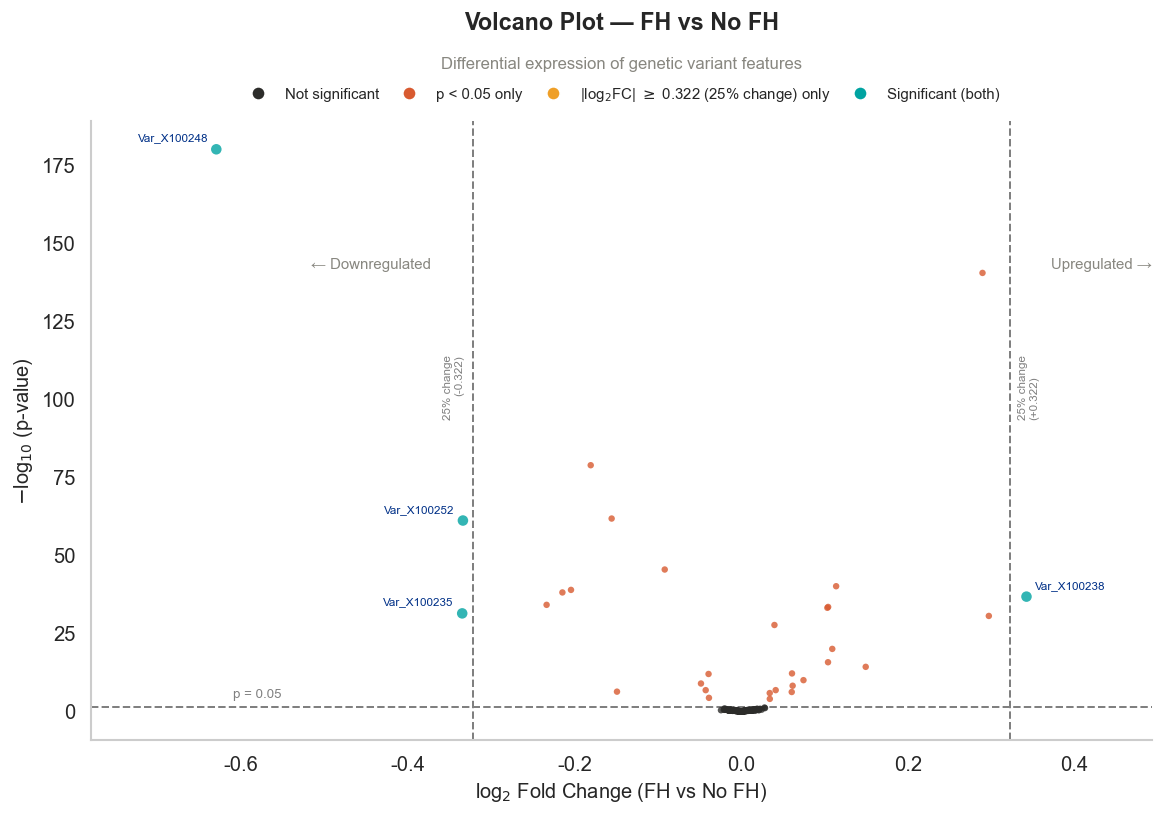

Not significant       234
p < 0.05 only          27
Significant (both)      4


In [13]:
from matplotlib.lines import Line2D

# significance thresholds
FC_THRESH = round(np.log2(1.25), 3)  # 25% expression change = log2(1.25) ≈ 0.322
P_THRESH  = 0.05

# define FH and No FH expression matrices
X_fh    = df[df[target] == "Familial_hypercholesterolemia"][gene_cols].values
X_no_fh = df[df[target] == "None"][gene_cols].values

# differential expression
_, p_vals = stats.ttest_ind(X_fh, X_no_fh, equal_var=False)
log2fc    = X_fh.mean(axis=0) - X_no_fh.mean(axis=0)

# build volcano dataframe
volcano_df = pd.DataFrame({
    "gene"           : gene_cols,
    "log2fc"         : log2fc,
    "pval"           : p_vals,
    "neg_log10_pval" : -np.log10(p_vals + 1e-300),
})

# assign significance label
def assign_colour(row):
    sig_p  = row["pval"]        < P_THRESH
    sig_fc = abs(row["log2fc"]) >= FC_THRESH
    if sig_p and sig_fc:   return "Significant (both)"
    elif sig_p:            return "p < 0.05 only"
    elif sig_fc:           return "|log₂FC| ≥ 0.05 only"
    else:                  return "Not significant"

volcano_df["category"] = volcano_df.apply(assign_colour, axis=1)

palette = {
    "Not significant"     : "#2C2C2A",
    "p < 0.05 only"       : ACCENT_RED,
    "|log₂FC| ≥ 0.05 only": "#EF9F27",
    "Significant (both)"  : BUPA_TEAL,
}

# plot
fig, ax = plt.subplots(figsize=(10, 7))
fig.subplots_adjust(top=0.82)
ax.set_facecolor("white")
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for cat, group in volcano_df.groupby("category"):
    ax.scatter(group["log2fc"], group["neg_log10_pval"],
               color=palette.get(cat, "#2C2C2A"),
               s=40 if cat == "Significant (both)" else 15,
               alpha=0.8, label=cat, edgecolors="none", zorder=2)

# threshold lines
ax.axhline(-np.log10(P_THRESH), color="grey", linestyle="--", linewidth=1.2, zorder=1)
ax.axvline( FC_THRESH,           color="grey", linestyle="--", linewidth=1.2, zorder=1)
ax.axvline(-FC_THRESH,           color="grey", linestyle="--", linewidth=1.2, zorder=1)

# extend x axis to fit all points
xpad = 0.15
ax.set_xlim(volcano_df["log2fc"].min() - xpad, volcano_df["log2fc"].max() + xpad)
ymax = ax.get_ylim()[1]

# threshold labels
ax.text( FC_THRESH + 0.01, ymax * 0.55, f"25% change\n(+{FC_THRESH})", fontsize=7, color="grey", ha="left",  rotation=90, va="center")
ax.text(-FC_THRESH - 0.01, ymax * 0.55, f"25% change\n(-{FC_THRESH})", fontsize=7, color="grey", ha="right", rotation=90, va="center")
ax.text(volcano_df["log2fc"].min() + 0.02, -np.log10(P_THRESH) + 3,
        f"p = {P_THRESH}", fontsize=8, color="grey", ha="left")

# directional labels 
ax.text( FC_THRESH + 0.05, ymax * 0.75, "Upregulated →",   fontsize=9, color=ACCENT_GREY, ha="left")
ax.text(-FC_THRESH - 0.05, ymax * 0.75, "← Downregulated", fontsize=9, color=ACCENT_GREY, ha="right")

# label significant genes 
sig = volcano_df[volcano_df["category"] == "Significant (both)"]
for i, (_, row) in enumerate(sig.iterrows()):
    offset_x = 5 if row["log2fc"] > 0 else -5
    offset_y = 5
    ax.annotate(row["gene"],
                xy=(row["log2fc"], row["neg_log10_pval"]),
                xytext=(offset_x, offset_y), textcoords="offset points",
                fontsize=7, color=BUPA_BLUE,
                ha="left" if offset_x > 0 else "right")

# axis labels and title
ax.set_xlabel("log$_2$ Fold Change (FH vs No FH)", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.set_ylabel("$-$log$_{10}$ (p-value)", fontsize=12)
ax.set_title("Volcano Plot — FH vs No FH", fontsize=14, fontweight="bold", pad=55)
ax.text(0.5, 1.08, "Differential expression of genetic variant features",
        transform=ax.transAxes, fontsize=10, color=ACCENT_GREY,
        ha="center", va="bottom")

# legend 
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2C2C2A", markersize=8, label="Not significant"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_RED,  markersize=8, label="p < 0.05 only"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#EF9F27",   markersize=8, label=r"|log$_2$FC| $\geq$ 0.322 (25% change) only"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=BUPA_TEAL,   markersize=8, label="Significant (both)"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9,
          loc="upper center", bbox_to_anchor=(0.5, 1.03),
          ncol=4, columnspacing=1)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2C2C2A", markersize=8, label="Not significant"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_RED,  markersize=8, label="p < 0.05 only"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#EF9F27",   markersize=8, label=r"|log$_2$FC| $\geq$ 0.322 (25% change) only"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=BUPA_TEAL,   markersize=8, label="Significant (both)"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9,
          loc="upper center", bbox_to_anchor=(0.5, 1.08),
          ncol=4, columnspacing=1)

plt.tight_layout()
plt.savefig("fig_volcano.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(volcano_df["category"].value_counts().to_string())

---
## Bubble Plot: Top Differentially Expressed Gene Variants

The bubble plot below provides a ranked, visual summary of the most significantly altered gene variants. 

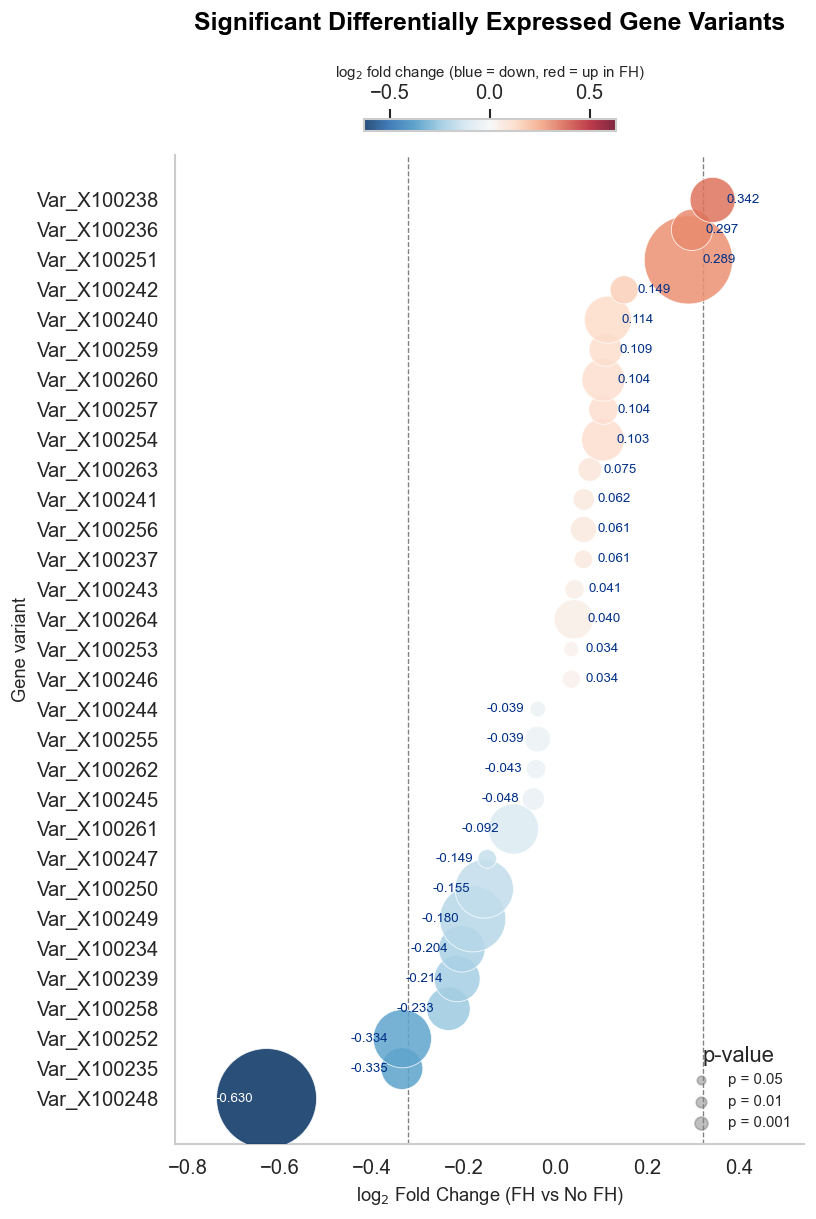

In [14]:
# bubble plot — all significant genes (p < 0.05), sorted by log2FC# FC threshold dashed lines only
ax.axvline( 0.322, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(-0.322, color="grey", linestyle="--", linewidth=0.8)

top_sig = (volcano_df[volcano_df["pval"] < P_THRESH]
           .sort_values("log2fc")
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7, max(4, len(top_sig) * 0.35)))
ax.set_facecolor("white")
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

sc = ax.scatter(
    top_sig["log2fc"],
    top_sig["gene"],
    s=top_sig["neg_log10_pval"] * 20,
    c=top_sig["log2fc"],
    cmap="RdBu_r",
    vmin=-top_sig["log2fc"].abs().max(),
    vmax= top_sig["log2fc"].abs().max(),
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=3
)


cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.4, pad=0.02, location="top")
cbar.set_label("log$_2$ fold change (blue = down, red = up in FH)", fontsize=9)

for p in [0.05, 0.01, 0.001]:
    ax.scatter([], [], s=-np.log10(p) * 20, c="grey", alpha=0.5, label=f"p = {p}")
ax.legend(title="p-value", frameon=False, loc="lower right", fontsize=9)

# FC threshold 
ax.axvline( 0.322, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(-0.322, color="grey", linestyle="--", linewidth=0.8)

# x axis 
xpad = 0.2
ax.set_xlim(top_sig["log2fc"].min() - xpad, top_sig["log2fc"].max() + xpad)


for _, row in top_sig.iterrows():
    text_color = "white" if row["gene"] == "Var_X100248" else BUPA_BLUE
    ax.text(row["log2fc"] + (0.03 if row["log2fc"] > 0 else -0.03),
            row["gene"],
            f"{row['log2fc']:.3f}",
            fontsize=8, color=text_color,
            va="center",
            ha="left" if row["log2fc"] > 0 else "right")

# axis labels and title
ax.set_xlabel("log$_2$ Fold Change (FH vs No FH)", fontsize=11)
ax.set_ylabel("Gene variant", fontsize=11)
ax.set_title("Significant Differentially Expressed Gene Variants",
             fontsize=15, fontweight="bold", color="black", pad=75)

plt.tight_layout()
plt.savefig("fig_bubble.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Section 2— Predictive Modelling

Predict familial hypercholsterolemia binary outcoems using genomic variant expressions and self-reported health measures.
### Approach

| Model | Rationale |
|---|---|
| **Logistic Regression (LASSO / L1)** | Sparse, interpretable; L1 penalty performs automatic feature selection, driving irrelevant gene coefficients to zero |
| **Random Forest** | provides built-in gene importance scores | may not handle correlated variables well
| **SVM (RBF kernel)** | Excellent in high-dimensional spaces; maximises margin between classes; C and γ tuned via cross-validation |


  Train+Val : 2208 samples (80%)
  Test      : 553 samples (20%) — held out
  FH prevalence — Train+Val : 80.2%
  FH prevalence — Test      : 80.1%

  Tuning hyperparameters via 5-fold CV on Train+Val only...

  Logistic (LASSO)           Best Val AUC = 0.993  | params: {'clf__C': 1.0}
  Random Forest              Best Val AUC = 0.995  | params: {'clf__max_depth': None, 'clf__n_estimators': 300}
  SVM (RBF)                  Best Val AUC = 0.999  | params: {'clf__C': 10.0, 'clf__gamma': 'scale'}

  ✓ Hyperparameter tuning complete

  Final test set evaluation (one-time, unbiased)

  Logistic (LASSO)
    AUC         : 0.996
    FH Recall   : 97.1%
    Specificity : 95.5%

  Random Forest
    AUC         : 0.994
    FH Recall   : 99.8%
    Specificity : 64.5%

  SVM (RBF)
    AUC         : 0.999
    FH Recall   : 100.0%
    Specificity : 98.2%


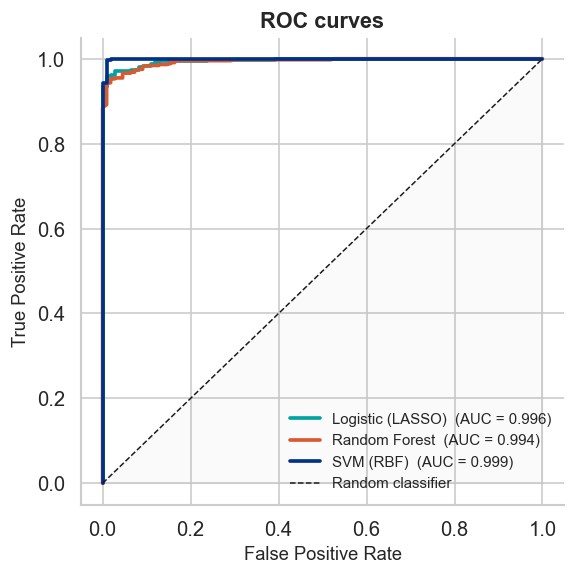

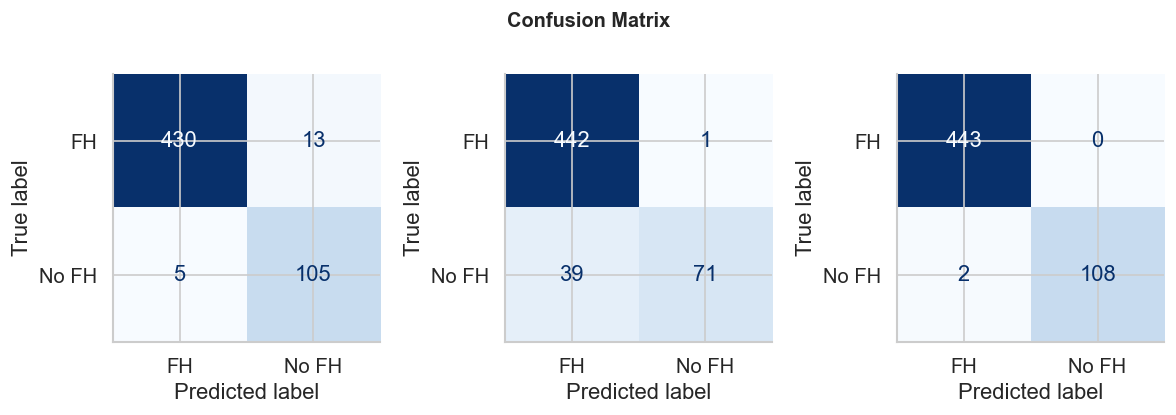


  Summary metrics — test set


Model,AUC,FH Recall,Specificity,Precision
Logistic (LASSO),0.996,97.1%,95.5%,98.9%
Random Forest,0.994,99.8%,64.5%,91.9%
SVM (RBF),0.999,100.0%,98.2%,99.6%


In [15]:
# define matrix and target
feature_cols = cov_cols + gene_cols
X_raw        = df[feature_cols].values
y_arr        = (df[target] == "Familial_hypercholesterolemia").astype(int).values

# train/test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y_arr, test_size=0.20, stratify=y_arr, random_state=42
)
print(f"  Train+Val : {X_trainval.shape[0]} samples ({X_trainval.shape[0]/len(X_raw)*100:.0f}%)")
print(f"  Test      : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_raw)*100:.0f}%) — held out")
print(f"  FH prevalence — Train+Val : {y_trainval.mean()*100:.1f}%")
print(f"  FH prevalence — Test      : {y_test.mean()*100:.1f}%")

# preprocessor
cat_cols_idx = [feature_cols.index(c) for c in ["Sex", "Physical_activity", "Mental_wellbeing"]]
num_cols_idx = [i for i in range(len(feature_cols)) if i not in cat_cols_idx]

def make_preprocessor():
    return ColumnTransformer([
        ("cat", OrdinalEncoder(), cat_cols_idx),
        ("num", StandardScaler(), num_cols_idx)
    ], remainder="passthrough")

# define models
base_models = {
    "Logistic (LASSO)": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear",
                                   class_weight="balanced",
                                   random_state=42, max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("clf", RandomForestClassifier(class_weight="balanced",
                                       random_state=42, n_jobs=-1))
    ]),
    "SVM (RBF)": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("clf", SVC(kernel="rbf", probability=True,
                    class_weight="balanced", random_state=42))
    ]),
}

param_grids = {
    "Logistic (LASSO)": {"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    "Random Forest"   : {"clf__n_estimators": [100, 300],
                         "clf__max_depth"   : [None, 10, 20]},
    "SVM (RBF)"       : {"clf__C"    : [0.01, 0.1, 1.0, 10.0, 100.0],
                         "clf__gamma": ["scale", "auto", 0.001, 0.01]}
}

# hyperparameter tuning
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n  Tuning hyperparameters via 5-fold CV on Train+Val only...\n")
best_models   = {}
best_params   = {}
best_val_aucs = {}

for name, pipeline in base_models.items():
    gs = GridSearchCV(pipeline, param_grids[name],
                      cv=inner_cv, scoring="roc_auc",
                      n_jobs=-1, verbose=0)
    gs.fit(X_trainval, y_trainval)
    best_models[name]   = gs.best_estimator_
    best_params[name]   = gs.best_params_
    best_val_aucs[name] = gs.best_score_
    print(f"  {name:25s}  Best Val AUC = {gs.best_score_:.3f}  | params: {gs.best_params_}")

print("\n  ✓ Hyperparameter tuning complete")

# final evaluation on test set
print("\n" + "=" * 60)
print("  Final test set evaluation (one-time, unbiased)")
print("=" * 60)
test_results = {}
for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred,
                                   target_names=["No FH", "FH"],
                                   output_dict=True)
    recall      = report["FH"]["recall"]
    specificity = report["No FH"]["recall"]
    test_results[name] = {
        "auc": auc, "y_prob": y_prob, "y_pred": y_pred,
        "recall": recall, "specificity": specificity
    }
    print(f"\n  {name}")
    print(f"    AUC         : {auc:.3f}")
    print(f"    FH Recall   : {recall*100:.1f}%")
    print(f"    Specificity : {specificity*100:.1f}%")

# ROC curves 
line_colors = {
    "Logistic (LASSO)": BUPA_TEAL,
    "Random Forest"   : ACCENT_RED,
    "SVM (RBF)"       : BUPA_BLUE,
}

fig, ax = plt.subplots(figsize=(5, 5))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr,
            label=f"{name}  (AUC = {res['auc']:.3f})",
            color=line_colors[name], linewidth=2.2)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.9, label="Random classifier")
ax.fill_between([0, 1], [0, 1], alpha=0.04, color="grey")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC curves", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("fig_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


# confusion matrices 
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, (name, res) in zip(axes, test_results.items()):
    cm   = confusion_matrix(y_test, res["y_pred"], labels=[1, 0])
    disp = ConfusionMatrixDisplay(cm, display_labels=["FH", "No FH"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.suptitle("Confusion Matrix", fontsize=12, fontweight="bold")
plt.subplots_adjust(wspace=0.01)
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# summary metrics table
print("\n" + "=" * 60)
print("  Summary metrics — test set")
print("=" * 60)

summary = pd.DataFrame({
    "Model"      : list(test_results.keys()),
    "AUC"        : [f"{r['auc']:.3f}" for r in test_results.values()],
    "FH Recall"  : [f"{r['recall']*100:.1f}%" for r in test_results.values()],
    "Specificity": [f"{r['specificity']*100:.1f}%" for r in test_results.values()],
    "Precision"  : [f"{classification_report(y_test, r['y_pred'], target_names=['No FH', 'FH'], output_dict=True)['FH']['precision']*100:.1f}%"
                    for r in test_results.values()],
})

summary.style \
    .set_properties(**{"text-align": "left", "font-size": "11px", "padding": "4px 8px"}) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#003087"), ("color", "white"),
                                     ("font-size", "11px"), ("padding", "4px 8px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f8ff")]},
    ]) \
    .hide(axis="index")

---
### Feature Importance: Which Gene Variants Are Most Influential?

1. **Random Forest importance** 
2. **LASSO coefficients** 


  Computing permutation importance on test set...



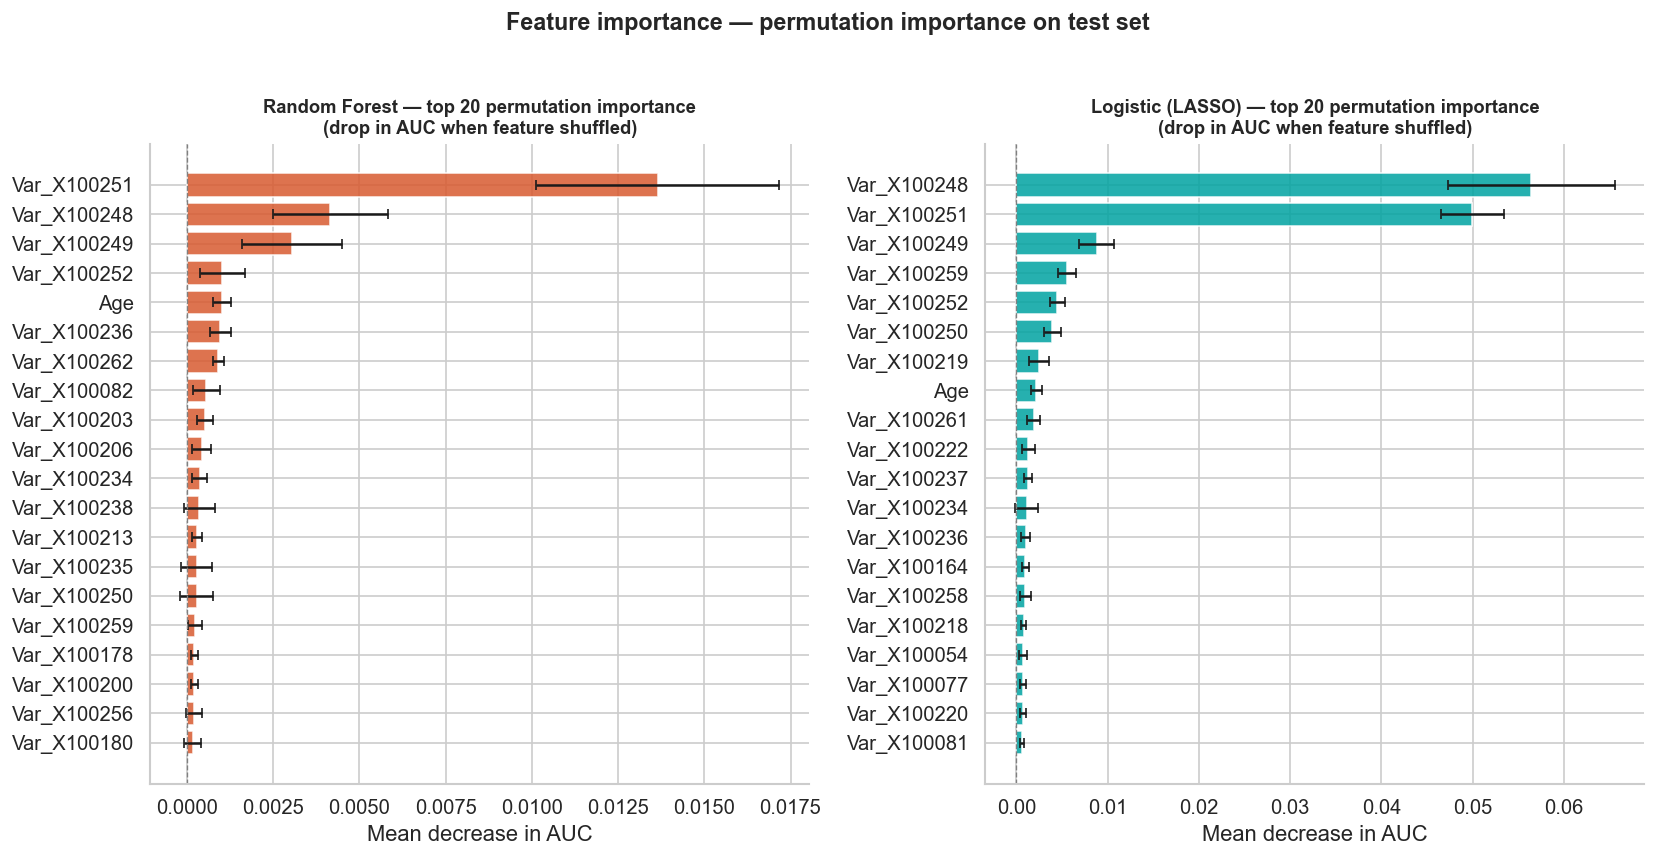


  Volcano plot significant genes: ['Var_X100235', 'Var_X100238', 'Var_X100248', 'Var_X100252']

  Consistency with volcano plot:
  Random Forest             top 20 ∩ volcano significant: 4 — ['Var_X100235', 'Var_X100238', 'Var_X100248', 'Var_X100252']
  Logistic (LASSO)          top 20 ∩ volcano significant: 2 — ['Var_X100248', 'Var_X100252']


In [16]:
# =============================================================================
# FEATURE IMPORTANCE 
# =============================================================================

# reconstruct feature names
cat_feature_names = ["Sex", "Physical_activity", "Mental_wellbeing"]
num_feature_names = [f for f in feature_cols if f not in cat_feature_names]
transformed_feature_names = cat_feature_names + num_feature_names

# permutation importance on test set 
print("  Computing permutation importance on test set...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (name, color) in zip(axes, [("Random Forest", ACCENT_RED),
                                     ("Logistic (LASSO)", BUPA_TEAL)]):
    # preprocess test set
    X_test_prep = best_models[name].named_steps["preprocessor"].transform(X_test)

    result = permutation_importance(
        best_models[name].named_steps["clf"],
        X_test_prep, y_test,
        n_repeats=10, random_state=42,
        scoring="roc_auc", n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "feature"   : transformed_feature_names,
        "importance": result.importances_mean,
        "std"       : result.importances_std
    }).sort_values("importance", ascending=False).head(20)

    ax.barh(perm_df["feature"], perm_df["importance"],
            xerr=perm_df["std"], color=color, alpha=0.85,
            edgecolor="white", capsize=3)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(f"{name} — top 20 permutation importance\n(drop in AUC when feature shuffled)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean decrease in AUC")
    ax.set_ylabel("")
    ax.invert_yaxis()

plt.suptitle("Feature importance — permutation importance on test set",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# consistency check with volcano plot
volcano_sig_genes = set(volcano_df[volcano_df["category"] == "Significant (both)"]["gene"].tolist())
print(f"\n  Volcano plot significant genes: {sorted(volcano_sig_genes)}")
print("\n  Consistency with volcano plot:")
for name in ["Random Forest", "Logistic (LASSO)"]:
    X_test_prep = best_models[name].named_steps["preprocessor"].transform(X_test)
    result = permutation_importance(
        best_models[name].named_steps["clf"],
        X_test_prep, y_test,
        n_repeats=10, random_state=42,
        scoring="roc_auc", n_jobs=-1
    )
    top_genes = set(
        pd.DataFrame({"feature": transformed_feature_names,
                      "importance": result.importances_mean})
        .sort_values("importance", ascending=False)
        .head(20)["feature"]
    ) & set(gene_cols)
    overlap = top_genes & volcano_sig_genes
    print(f"  {name:25s} top 20 ∩ volcano significant: {len(overlap)} — {sorted(overlap)}")

## Section 3 — Limitations 

---

| Limitation | Detail | Impact |
|---|---|---|
| **Class imbalance** | 80/20 FH/Control split — does not reflect true UK prevalence (~1 in 250) | Model may be optimistic; addressed via class_weight='balanced'  |
| **No LDL/lipid panel** | LDL-C, HDL-C and total cholesterol absent from dataset | Missing the primary clinical FH diagnostic marker — would likely be the strongest predictor |
| **Single time point** | Gene expression measured once per patient | Expression levels fluctuate with medication, lifestyle and stress — a single snapshot may not be representative |
